In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/rossmann-store-sales/sample_submission.csv
/kaggle/input/rossmann-store-sales/store.csv
/kaggle/input/rossmann-store-sales/train.csv
/kaggle/input/rossmann-store-sales/test.csv


In [2]:
pip install prophet

Note: you may need to restart the kernel to use updated packages.


In [3]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import datetime

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from statsmodels.distributions.empirical_distribution import ECDF

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from prophet import Prophet

In [4]:
# importing train data to learn
train = pd.read_csv("/kaggle/input/rossmann-store-sales/train.csv",parse_dates=True, low_memory=False, index_col = 'Date')
train.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
Date,,,,,,,,
2015-07-31,1,5,5263,555,1,1,0,1
2015-07-31,2,5,6064,625,1,1,0,1
2015-07-31,3,5,8314,821,1,1,0,1
2015-07-31,4,5,13995,1498,1,1,0,1
2015-07-31,5,5,4822,559,1,1,0,1


In [5]:
# additional store data
store = pd.read_csv("/kaggle/input/rossmann-store-sales/store.csv",low_memory=False)
train.index

DatetimeIndex(['2015-07-31', '2015-07-31', '2015-07-31', '2015-07-31',
               '2015-07-31', '2015-07-31', '2015-07-31', '2015-07-31',
               '2015-07-31', '2015-07-31',
               ...
               '2013-01-01', '2013-01-01', '2013-01-01', '2013-01-01',
               '2013-01-01', '2013-01-01', '2013-01-01', '2013-01-01',
               '2013-01-01', '2013-01-01'],
              dtype='datetime64[ns]', name='Date', length=1017209, freq=None)

### EDA

In [6]:
print("In total: ", train.shape)
train.head()

In total:  (1017209, 8)


,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
Date,,,,,,,,
2015-07-31,1,5,5263,555,1,1,0,1
2015-07-31,2,5,6064,625,1,1,0,1
2015-07-31,3,5,8314,821,1,1,0,1
2015-07-31,4,5,13995,1498,1,1,0,1
2015-07-31,5,5,4822,559,1,1,0,1


Short description:¶
1. Sales: the turnover for any given day (target variable).
2. Customers: the number of customers on a given day.
3. Open: an indicator for whether the store was open: 0 = closed, 1 = open.
4. Promo: indicates whether a store is running a promo on that day.
5. StateHoliday: indicates a state holiday. Normally all stores, with few exceptions, are closed on state holidays.
6. SchoolHoliday: indicates if the (Store, Date) was affected by the closure of public schools.

In [7]:
# data extraction
train['Year'] = train.index.year
train['Month'] = train.index.month
train['Day'] = train.index.day
train['WeekOfYear'] = train.index.isocalendar().week



In [8]:
# adding new variable
train['SalePerCustomer'] = train['Sales']/train['Customers']
train['SalePerCustomer'].describe()

count    844340.000000
mean          9.493619
std           2.197494
min           0.000000
25%           7.895563
50%           9.250000
75%          10.899729
max          64.957854
Name: SalePerCustomer, dtype: float64

### ECDF: empirical cumulative distribution function

Text(0.5, 0, 'Sale per Customer')

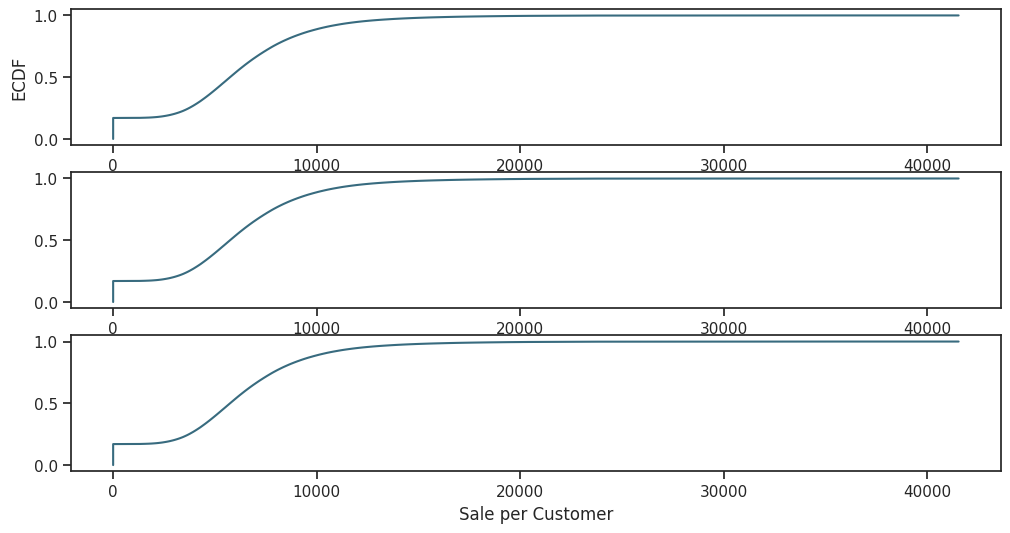

In [9]:
sns.set(style='ticks')
color='#386B7F'
plt.figure(figsize=(12,6))

plt.subplot(311)
cdf = ECDF(train['Sales'])
plt.plot(cdf.x,cdf.y,label = "statmodels",color=color)
plt.xlabel('Sales')
plt.ylabel('ECDF')

plt.subplot(312)
cf = ECDF(train['Customers'])
plt.plot(cdf.x,cdf.y,label = "statmodels",color=color)
plt.xlabel('Customers')

plt.subplot(313)
cf = ECDF(train['SalePerCustomer'])
plt.plot(cdf.x,cdf.y,label = "statmodels",color=color)
plt.xlabel('Sale per Customer')